Step 2: Data Collection (Simulated)
Flight data head:
   DayOfWeek       Date  DepTime  ArrTime  CRSArrTime UniqueCarrier  \
0          7 2024-05-04      647      269        2255            AA   
1          4 2024-01-08      600     1113         480            AA   
2          5 2024-12-05     1111      371          82            UA   
3          3 2024-10-24      857      226         898            UA   
4          7 2024-09-06      367      192         144            DL   

              Airline  FlightNum TailNum  ActualElapsedTime  ...  TaxiIn  \
0     United Airlines       1026   N6030                130  ...       9   
1      Delta Airlines        648   N3008                213  ...      29   
2  Southwest Airlines        307   N6832                154  ...      25   
3      Delta Airlines       1198   N1409                290  ...      24   
4  Southwest Airlines       1001   N7781                270  ...      21   

   TaxiOut  Cancelled CancellationCode Diverted CarrierDelay W

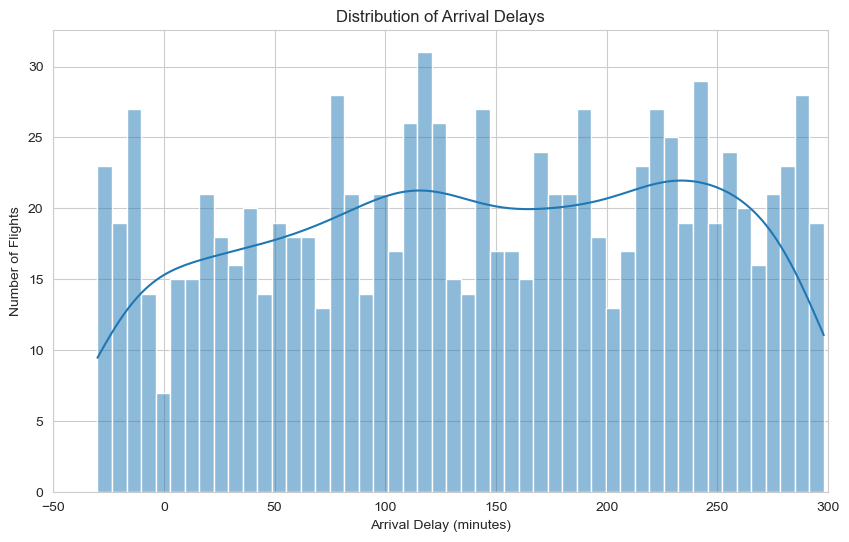

C:\Users\sweth\AppData\Local\Temp\ipykernel_19864\2584302268.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_delay_airline_original.values, y=avg_delay_airline_original.index, palette='viridis')


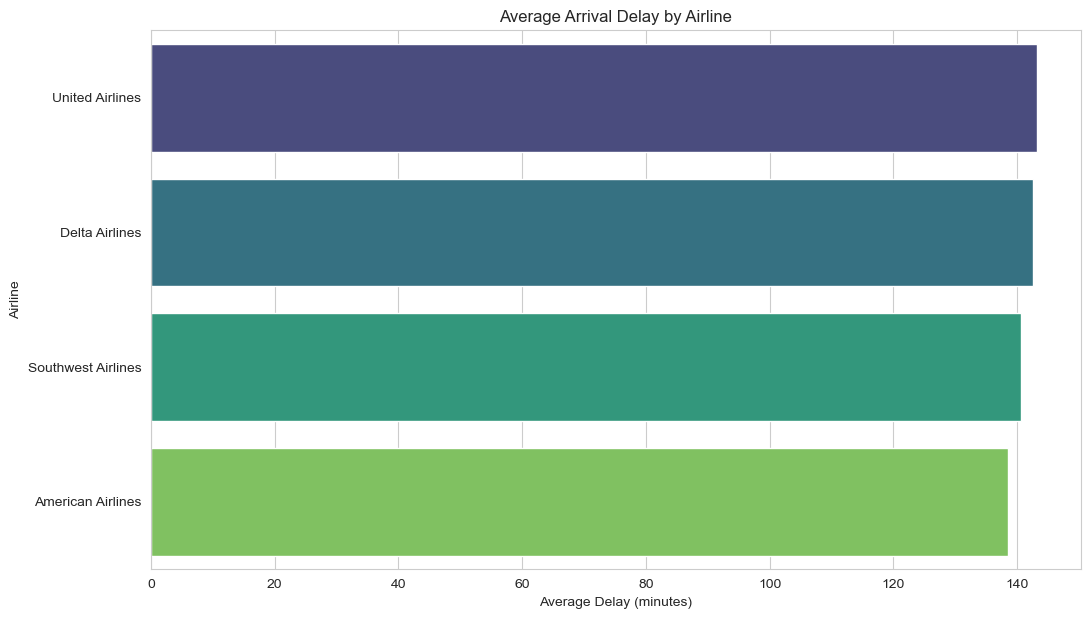

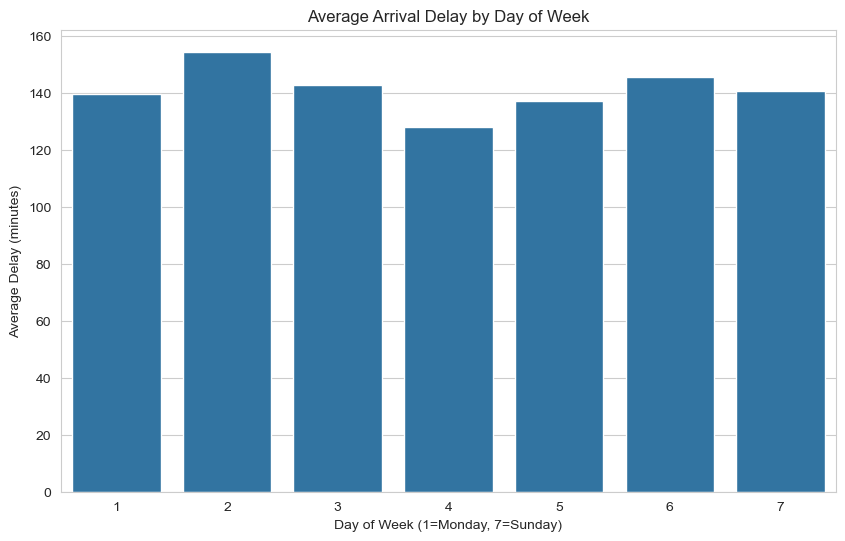

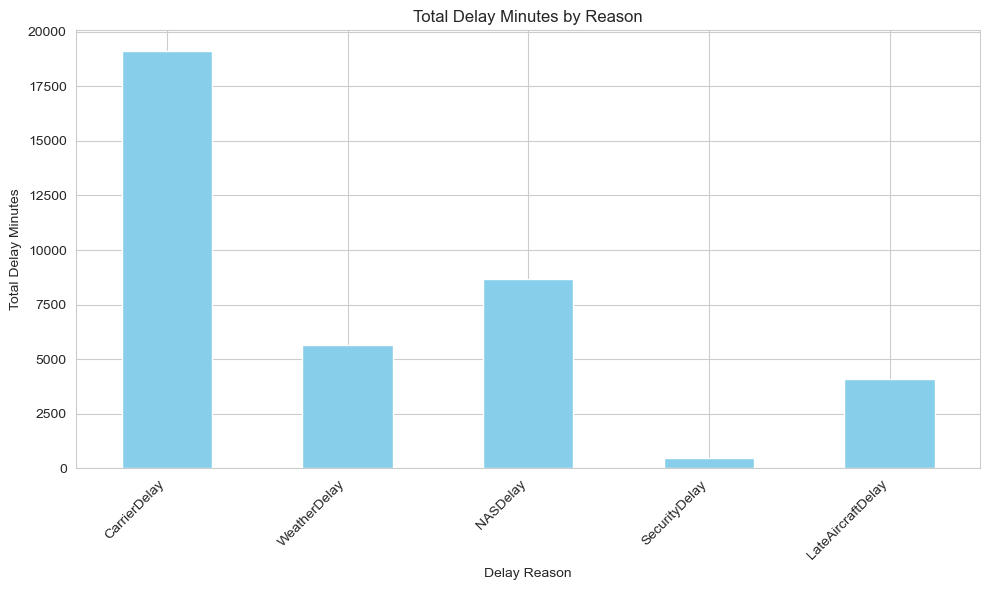

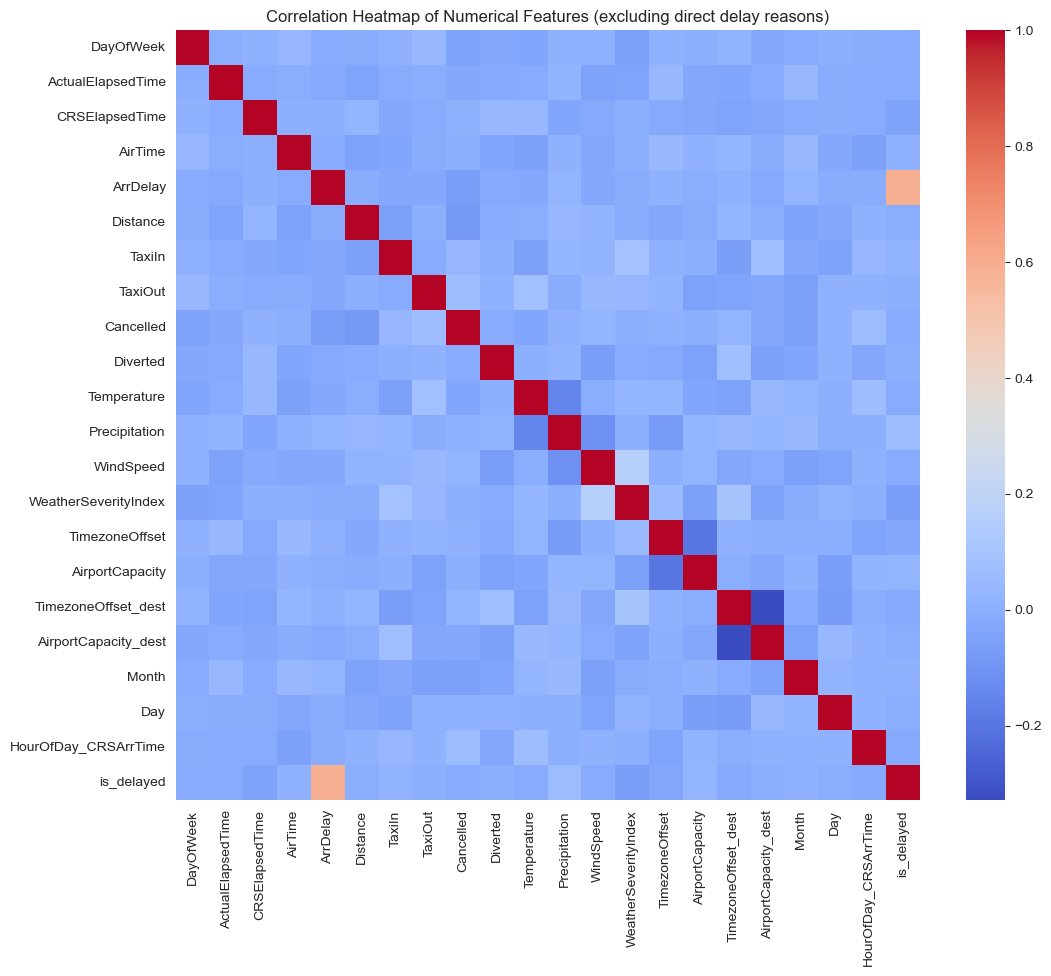


Step 5: Model Building (ML)
X_train shape: (800, 40), y_train shape: (800,)
X_test shape: (200, 40), y_test shape: (200,)

--- Training Logistic Regression ---

--- Evaluating Logistic Regression ---
Accuracy: 0.8750
Precision: 0.8794
Recall: 0.9943
ROC-AUC: 0.4503
Confusion Matrix:


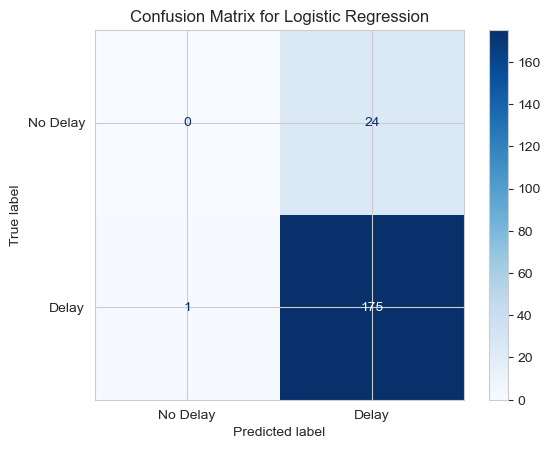


Feature Coefficients (Logistic Regression):
                 Feature  Coefficient
37    CancellationCode_C    -0.839534
39  CancellationCode_nan     0.444353
32              Dest_LAS     0.321292
36    CancellationCode_B     0.317806
12  WeatherSeverityIndex    -0.308782
30            Origin_LAX    -0.279785
31            Origin_ORD     0.254365
29            Origin_DFW     0.249368
23      UniqueCarrier_UA     0.186995
34              Dest_SEA    -0.184892


C:\Users\sweth\AppData\Local\Temp\ipykernel_19864\2584302268.py:192: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_coef_df.head(10), palette='coolwarm')


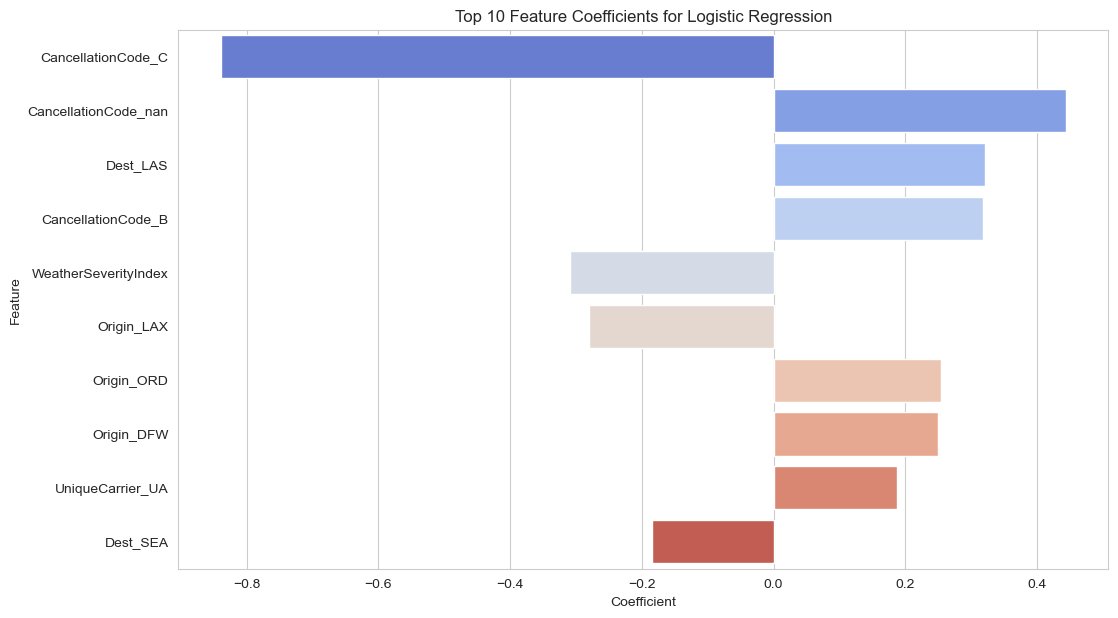


--- Training Random Forest ---

--- Evaluating Random Forest ---
Accuracy: 0.8800
Precision: 0.8800
Recall: 1.0000
ROC-AUC: 0.5342
Confusion Matrix:


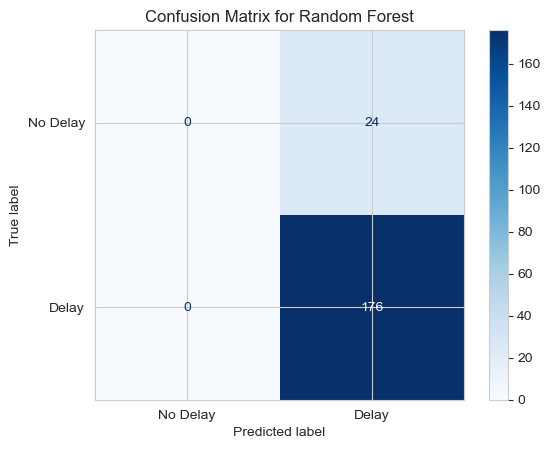


Feature Importances:
                 Feature  Importance
4               Distance    0.080725
3                AirTime    0.078581
2         CRSElapsedTime    0.076706
1      ActualElapsedTime    0.074690
20                   Day    0.067207
6                TaxiOut    0.059515
21  HourOfDay_CRSArrTime    0.059472
5                 TaxiIn    0.054125
19                 Month    0.044457
0              DayOfWeek    0.039626


C:\Users\sweth\AppData\Local\Temp\ipykernel_19864\2584302268.py:179: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='magma')


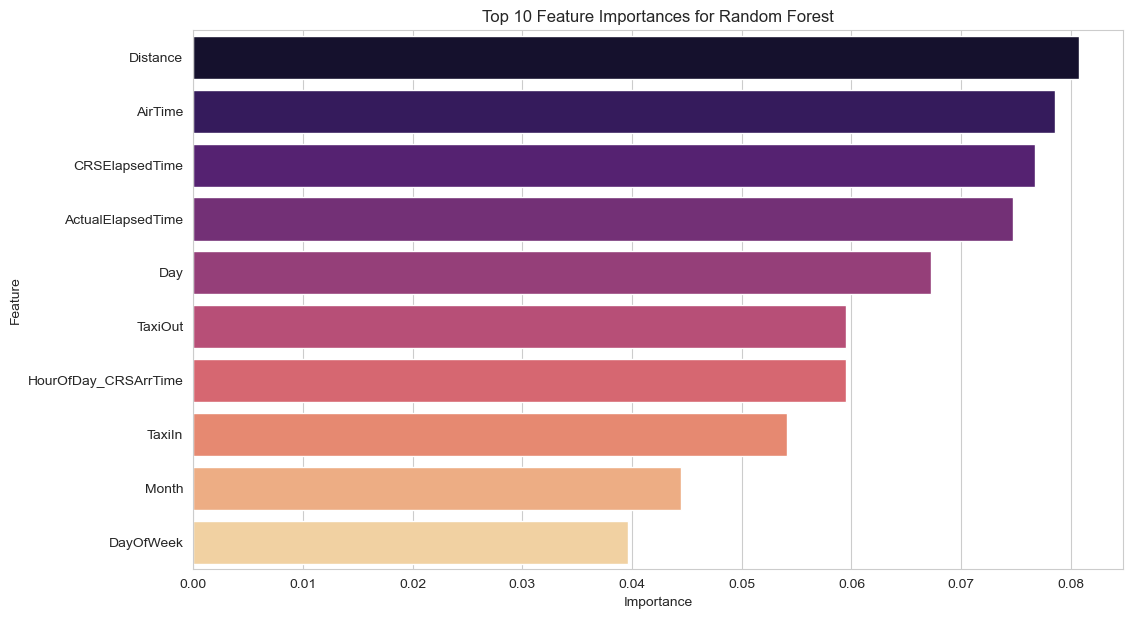


--- Training XGBoost ---

--- Evaluating XGBoost ---
Accuracy: 0.8750
Precision: 0.8832
Recall: 0.9886
ROC-AUC: 0.6418
Confusion Matrix:


C:\Users\sweth\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:57:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


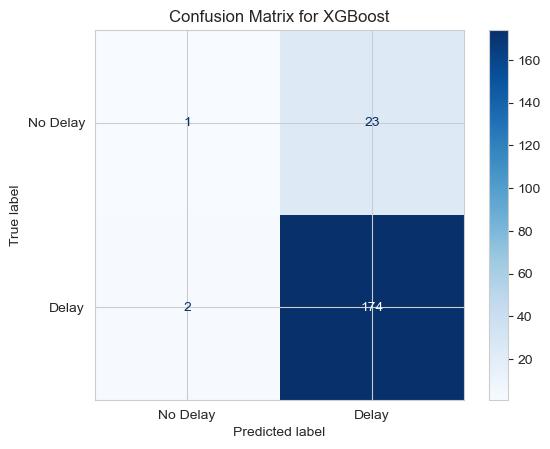


Feature Importances:
                    Feature  Importance
39     CancellationCode_nan    0.160222
37       CancellationCode_C    0.112187
10            Precipitation    0.081105
11                WindSpeed    0.055819
12     WeatherSeverityIndex    0.044667
35                 Dest_SFO    0.034514
22         UniqueCarrier_DL    0.034165
0                 DayOfWeek    0.033880
27  Airline_United Airlines    0.033161
23         UniqueCarrier_UA    0.031540


C:\Users\sweth\AppData\Local\Temp\ipykernel_19864\2584302268.py:179: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='magma')


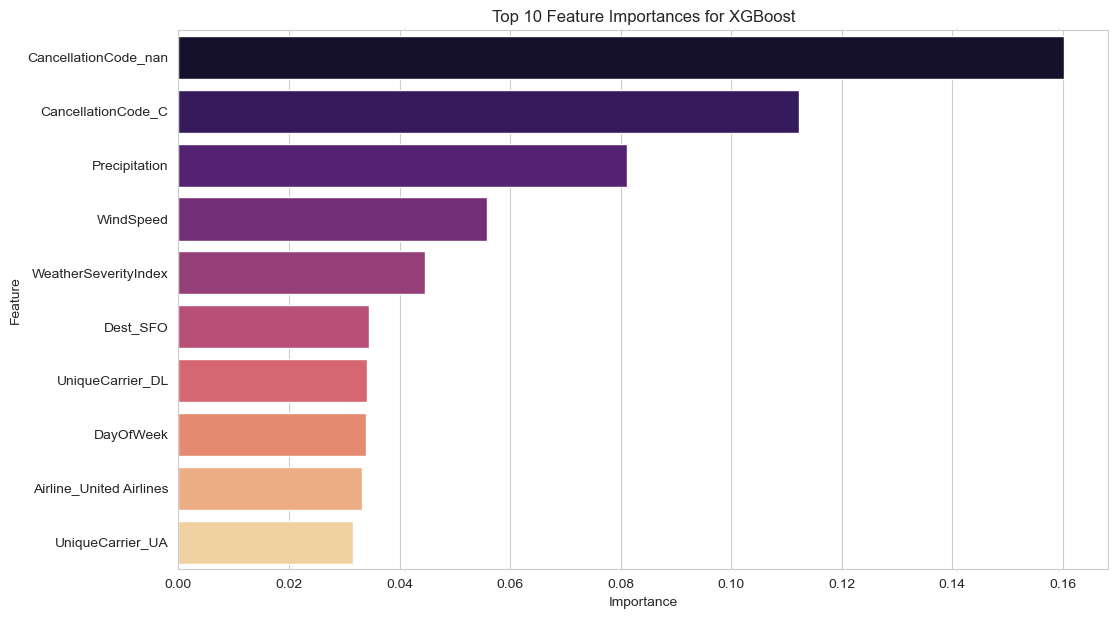

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
print("Step 2: Data Collection (Simulated)")
num_flights = 1000
flight_data = {
    'DayOfWeek': np.random.randint(1, 8, num_flights), 
    'Date': pd.to_datetime('2024-01-01') + pd.to_timedelta(np.random.randint(0, 365, num_flights), unit='D'), 
    'DepTime': np.random.randint(0, 2400, num_flights), 
    'ArrTime': np.random.randint(0, 2400, num_flights), 
    'CRSArrTime': np.random.randint(0, 2400, num_flights), 
    'UniqueCarrier': np.random.choice(['AA', 'UA', 'DL', 'WN'], num_flights), 
    'Airline': np.random.choice(['American Airlines', 'United Airlines', 'Delta Airlines', 'Southwest Airlines'], num_flights), 
    'FlightNum': np.random.randint(1, 2000, num_flights), 
    'TailNum': ['N' + str(i).zfill(4) for i in np.random.randint(1000, 9999, num_flights)], 
    'ActualElapsedTime': np.random.randint(60, 300, num_flights), 
    'CRSElapsedTime': np.random.randint(60, 300, num_flights), 
    'AirTime': np.random.randint(50, 290, num_flights), 
    'ArrDelay': np.random.randint(-30, 300, num_flights), 
    'Origin': np.random.choice(['ATL', 'LAX', 'ORD', 'DFW', 'DEN'], num_flights), 
    'Org_Airport': np.random.choice(['Hartsfield-Jackson Atlanta', 'Los Angeles Intl', 'Chicago O\'Hare Intl', 'Dallas/Fort Worth Intl', 'Denver Intl'], num_flights), 
    'Dest': np.random.choice(['JFK', 'SFO', 'MIA', 'SEA', 'LAS'], num_flights), 
    'Dest_Airport': np.random.choice(['John F. Kennedy Intl', 'San Francisco Intl', 'Miami Intl', 'Seattle-Tacoma Intl', 'McCarran Intl'], num_flights), 
    'Distance': np.random.randint(100, 2000, num_flights), 
    'TaxiIn': np.random.randint(5, 30, num_flights), 
    'TaxiOut': np.random.randint(10, 40, num_flights), 
    'Cancelled': np.random.choice([0, 1], num_flights, p=[0.98, 0.02]), 
    'CancellationCode': np.random.choice(['A', 'B', 'C', 'D', np.nan], num_flights, p=[0.005, 0.005, 0.005, 0.005, 0.98]),
    'Diverted': np.random.choice([0, 1], num_flights, p=[0.99, 0.01]), 
    'CarrierDelay': np.random.choice([0, np.random.randint(1, 100)], num_flights, p=[0.8, 0.2]), 
    'WeatherDelay': np.random.choice([0, np.random.randint(1, 100)], num_flights, p=[0.9, 0.1]), 
    'NASDelay': np.random.choice([0, np.random.randint(1, 100)], num_flights, p=[0.85, 0.15]), 
    'SecurityDelay': np.random.choice([0, np.random.randint(1, 100)], num_flights, p=[0.99, 0.01]), 
    'LateAircraftDelay': np.random.choice([0, np.random.randint(1, 100)], num_flights, p=[0.8, 0.2]), 
}
df_flights = pd.DataFrame(flight_data)
weather_data = {
    'Date': pd.to_datetime('2024-01-01') + pd.to_timedelta(np.arange(365), unit='D'),
    'Origin': np.random.choice(['ATL', 'LAX', 'ORD', 'DFW', 'DEN'], 365),
    'Temperature': np.random.randint(10, 35, 365),
    'Precipitation': np.random.rand(365) * 10,
    'WindSpeed': np.random.randint(5, 50, 365),
    'WeatherSeverityIndex': np.random.rand(365) * 5 
}
df_weather = pd.DataFrame(weather_data)
airport_metadata = {
    'IATA': ['ATL', 'LAX', 'ORD', 'DFW', 'DEN', 'JFK', 'SFO', 'MIA', 'SEA', 'LAS'],
    'TimezoneOffset': np.random.randint(-8, 5, 10), 
    'IsHub': np.random.choice([True, False], 10),
    'AirportCapacity': np.random.randint(50, 200, 10)
}
df_airports = pd.DataFrame(airport_metadata)
print("Flight data head:")
print(df_flights.head())
print("\nWeather data head:")
print(df_weather.head())
print("\nAirport metadata head:")
print(df_airports.head())
print("\nStep 3: Data Preprocessing")
df = df_flights.copy()
df = pd.merge(df, df_weather, on=['Date', 'Origin'], how='left')
df = pd.merge(df, df_airports.rename(columns={'IATA': 'Origin'}), on='Origin', how='left', suffixes=('', '_origin'))
df = pd.merge(df, df_airports.rename(columns={'IATA': 'Dest'}), on='Dest', how='left', suffixes=('', '_dest'))
print(f"Shape after initial merges: {df.shape}")
for col in ['Temperature', 'Precipitation', 'WindSpeed', 'WeatherSeverityIndex',
            'TimezoneOffset', 'IsHub', 'AirportCapacity',
            'TimezoneOffset_dest', 'IsHub_dest', 'AirportCapacity_dest']:
    if col in df.columns:
        if df[col].dtype in ['int64', 'float64', 'bool']: 
            df[col] = df[col].fillna(df[col].median() if df[col].dtype != 'bool' else False) 
        else:
            df[col] = df[col].fillna('Unknown')
df['CancellationCode'] = df['CancellationCode'].fillna('No Cancellation')
df = df.drop(columns=['TailNum', 'FlightNum', 'DepTime', 'ArrTime', 'Org_Airport', 'Dest_Airport'], errors='ignore')
print(f"Shape after dropping columns: {df.shape}")
print("Missing values after initial handling:")
print(df.isnull().sum()[df.isnull().sum() > 0]) 
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['HourOfDay_CRSArrTime'] = (df['CRSArrTime'] // 100) % 24 
df = df.drop(columns=['Date', 'CRSArrTime'], errors='ignore')
df['is_delayed'] = (df['ArrDelay'] > 15).astype(int)
categorical_cols_to_encode = ['UniqueCarrier', 'Airline', 'Origin', 'Dest', 'CancellationCode']
df = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True) 
print(f"Shape after one-hot encoding: {df.shape}")
print("\nFeatures after preprocessing:")
print(df.columns.tolist())
print("\nFirst 5 rows of preprocessed data:")
print(df.head())
print("\nStep 4: Exploratory Data Analysis (EDA)")
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(df['ArrDelay'], bins=50, kde=True)
plt.title('Distribution of Arrival Delays')
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Number of Flights')
plt.xlim(-50, 300) 
plt.show()
plt.figure(figsize=(12, 7))
avg_delay_airline_original = df_flights.groupby('Airline')['ArrDelay'].mean().sort_values(ascending=False)
sns.barplot(x=avg_delay_airline_original.values, y=avg_delay_airline_original.index, palette='viridis')
plt.title('Average Arrival Delay by Airline')
plt.xlabel('Average Delay (minutes)')
plt.ylabel('Airline')
plt.show()
plt.figure(figsize=(10, 6))
sns.barplot(x='DayOfWeek', y='ArrDelay', data=df_flights.groupby('DayOfWeek')['ArrDelay'].mean().reset_index())
plt.title('Average Arrival Delay by Day of Week')
plt.xlabel('Day of Week (1=Monday, 7=Sunday)')
plt.ylabel('Average Delay (minutes)')
plt.show()
delay_reasons = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
total_delays_by_reason = df[delay_reasons].sum()
plt.figure(figsize=(10, 6))
total_delays_by_reason.plot(kind='bar', color='skyblue')
plt.title('Total Delay Minutes by Reason')
plt.xlabel('Delay Reason')
plt.ylabel('Total Delay Minutes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 10))
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
cols_for_corr = [col for col in numerical_cols if col not in delay_reasons]
sns.heatmap(df[cols_for_corr].corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features (excluding direct delay reasons)')
plt.show()
print("\nStep 5: Model Building (ML)")
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
X = df.drop(columns=['ArrDelay', 'is_delayed'] + delay_reasons, errors='ignore')
y = df['is_delayed'] 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
X_train.columns = [str(col) for col in X_train.columns]
X_test.columns = [str(col) for col in X_test.columns]
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='liblinear', random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        use_label_encoder=False, 
        eval_metric='logloss',
        random_state=42,
    )
}
for name, model in models.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] 
    print(f"\n--- Evaluating {name} ---")
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print("Confusion Matrix:")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Delay', 'Delay'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {name}')
    plt.show()
    if hasattr(model, 'feature_importances_'):
        print("\nFeature Importances:")
        importances = model.feature_importances_
        feature_names = X.columns
        feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
        print(feature_importance_df.head(10)) 
        plt.figure(figsize=(12, 7))
        sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='magma')
        plt.title(f'Top 10 Feature Importances for {name}')
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        plt.show()
    elif hasattr(model, 'coef_'): 
        print("\nFeature Coefficients (Logistic Regression):")
        coefficients = model.coef_[0]
        feature_names = X.columns
        feature_coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
        feature_coef_df = feature_coef_df.reindex(feature_coef_df['Coefficient'].abs().sort_values(ascending=False).index)
        print(feature_coef_df.head(10)) 
        plt.figure(figsize=(12, 7))
        sns.barplot(x='Coefficient', y='Feature', data=feature_coef_df.head(10), palette='coolwarm')
        plt.title(f'Top 10 Feature Coefficients for {name}')
        plt.xlabel('Coefficient')
        plt.ylabel('Feature')
        plt.show()